# 07 — Functional Maps

**The question:** instead of matching $n$ points to $n$ other points, can we represent the correspondence as a small matrix that is easier to compute and optimise?

## Intuition

A point-to-point map $T: V_A \to V_B$ induces a **pullback** $T^*$ on functions: $(T^* f)(j) = f(T[j])$.

The key insight of the functional maps framework (Ovsjanikov et al., 2012) is:

> **Instead of finding $T$ directly, find the linear map $T^*$ in the spectral domain.**

In the truncated eigenbasis $\{\phi_k^A\}$ and $\{\phi_k^B\}$, the pullback $T^*$ becomes a small matrix $C \in \mathbb{R}^{K_B \times K_A}$. Computing and optimising a $K \times K$ matrix (with $K \approx 30$–$200$) is *much* cheaper than working with an $n \times n$ permutation matrix.

## Minimal math

**From p2p to functional map.** Given $T$, the functional map matrix is:

$$C_{ij} = \langle \phi_j^B,\, T^* \phi_i^A \rangle_B = \sum_{v \in V_B} \phi_j^B(v)\, \phi_i^A(T[v])\, a_v$$

In matrix form:

$$C = \Phi_B^\top M_B\, \Phi_A[T, :]$$

where $\Phi_A[T, :]$ gathers rows of $\Phi_A$ indexed by the map $T$.

**Applying $C$ to a function.** If $\mathbf{a} = \Phi_A^\top M_A \mathbf{f}$ are the spectral coefficients of $f$ on $A$, then:

$$\text{spectral coefficients of } T^*f \text{ on } B \approx C\mathbf{a}$$

**Isometry implies orthogonality.** If $T$ is an isometry, then $C$ is an orthogonal matrix: $C^\top C = I$. This gives a powerful constraint for optimisation.

**Efficiency:** $C$ has $K^2$ entries vs $n_A n_B$ for a full matrix. With $K=100$ and $n=7000$, this is a $4900$ vs $49\,000\,000$ difference.

In [1]:
import matplotlib.pyplot as plt

from geomfum.convert import FmFromP2pConverter
from geomfum.dataset import NotebooksDataset
from geomfum.shape import TriangleMesh

In [2]:
dataset = NotebooksDataset()
mesh_a = TriangleMesh.from_file(dataset.get_filename("cat-00"))
mesh_b = TriangleMesh.from_file(dataset.get_filename("lion-00"))

K = 30
mesh_a.laplacian.find_spectrum(spectrum_size=K, set_as_basis=True)
mesh_b.laplacian.find_spectrum(spectrum_size=K, set_as_basis=True)

print(f"A: {mesh_a.n_vertices} vertices,  basis: {mesh_a.basis.vecs.shape}")
print(f"B: {mesh_b.n_vertices} vertices,  basis: {mesh_b.basis.vecs.shape}")

A: 7207 vertices,  basis: (7207, 30)
B: 5000 vertices,  basis: (5000, 30)


## From a p2p map to a functional map

The formula $C = \Phi_B^\top M_B \Phi_A[T,:]$ is implemented in `FmFromP2pConverter`. Here we use a near-identity map (matching vertices by 3D proximity) just to see the matrix structure.

In [3]:
from geomfum.convert import NeighborFinder

# Build a simple nearest-neighbour p2p map B -> A
nn = NeighborFinder()
p2p_nn = nn(mesh_b.vertices, mesh_a.vertices).flatten()  # (n_b,)

fm_conv = FmFromP2pConverter()
C_nn = fm_conv(p2p_nn, mesh_a.basis, mesh_b.basis)  # (K_B, K_A)
print(f"C shape: {C_nn.shape}  (K_B x K_A)")

C shape: (30, 30)  (K_B x K_A)


## Visualise $C$

For a perfect isometric map, $C$ should be the identity matrix. For a near-isometric map (cat and lion share rough topology), $C$ should be close to diagonal.

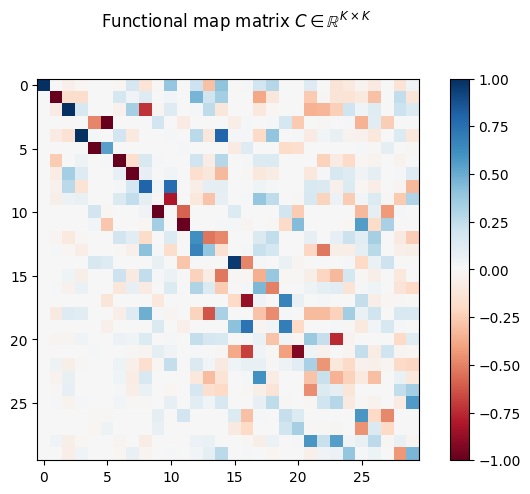

In [4]:
plt.imshow(C_nn, cmap="RdBu", vmin=-1, vmax=1)

plt.colorbar()
plt.suptitle("Functional map matrix $C \\in \\mathbb{R}^{K \\times K}$", y=1.02)
plt.tight_layout()
plt.show()

Generally, Functional maps based methods Optimize the fucntional maps, which is compact and easier to optimize, to then recove rhte correspondence.

## Where to go next

- [08 — Signal Transfer with Functional Maps](./08_signal_transfer.ipynb): use $C$ to transfer functions from $A$ to $B$
- [How to compute a functional map?](../how_to/07_functional_map.ipynb)
- [How to compute a p2p map from a functional map?](../how_to/10_pointwise_from_functional.ipynb)